<a href="https://colab.research.google.com/github/fpinell/hands_on_python_for_ds/blob/main/notebooks/phd/2026/Lecture_1_Pandas_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning with Python

### IMT PhD - 2025-2026

#### Fabio Pinelli
<a href="mailto:fabio.pinelli@imtlucca.it">fabio.pinelli@imtlucca.it</a><br/>
IMT School for Advanced Studies Lucca<br/>
2025/2026<br/>
April, 29 2026

# Program

1) Introduction to Python for data science
* Introduction to pandas and jupyter
* Dataframes, manipulation, and typical operations
* Reading from files
* Plotting libraries

2) Unsupervised learning (some example)
* Introduction to unsupervised learning
* Examples with k-means
* Examples with hierarchical clustering
* Examples with density based clustering


3) Supervised learning
* Scikit-learn for classification/regression
* Pipeline and data handling
* Random Forest / XGBoost / SVM / etc.
* Classification evaluation

4) Neural networks and deep learning
* Introduction and recap
* Implementation in Python
* Deep learning:
  - Introduction to Pytorch
  - RNN
  - CNN

  
5a) Self-supervised learning
* Introduction to self-supervised learning
  - Reconstruction loss
  - Contrastive learning
  - Other methods
* Some example


5b) eXplainable AI (XAI)
* Introduction
* Some libraries
  - SHAP
  - LIME
* Examples

## Material
 * Books:
  + Hands-on Machine Learning with Scikit-learn, Keras & TensorFlow
  + Programming PyTorch for Deep Learning
  + Deep learning with pytorch step-by-step

* Tools:
  - python, pytorch
  - pandas, matplotlib, Scikit-learn
  - Google colab

* Exam:
 You don't have any exam/projects, but if you want to collaborate on some of my projects and data you are more than welcome.

* Material (notebooks):
 - here a github repository with all the notebooks we will use in the lessons.
 - https://github.com/fpinell/hands_on_python_for_ds/tree/main/notebooks/phd/2026



# Lecture 1 — Pandas in a real workflow

**Hands-on Python for Data Science — PhD Course**

In this lecture we open a real-looking dataset of apartment rentals in Milan
and follow the workflow of a data scientist meeting a new dataset for the first time:

1. Load it and look at it
2. Select and filter
3. Clean it (this is where most of the time goes)
4. Aggregate and summarize
5. Join with other tables
6. Visualize it

Along the way we introduce the parts of `pandas` we need —
**when we need them**, not as an abstract reference manual.

> **A note on LLMs.** You are encouraged to use LLMs (ChatGPT, Claude, Copilot, …)
> alongside this notebook. We will mark a few **🛑 LLM checkpoints** where I
> explicitly suggest you try asking your LLM and then *verify* the answer.
> The skill we are training is not "writing pandas code" — LLMs do that.
> The skill is **knowing what to ask, and recognizing when the answer is wrong**.

---
## 0. Notebooks and Python environments — a quick primer

Before we touch any data, let's make sure we share the same mental model of
the tools we are using. This 10-minute section is for everyone, but especially
for those who tried Jupyter and gave up.

### 0.1 What is a Jupyter notebook?

A notebook is a file made of **cells**. Two main kinds:

- **Markdown cells** — text, like this one.
- **Code cells** — Python code that runs.

The code is executed by a **kernel**, which is a Python process that lives in
the background while the notebook is open. The kernel keeps **state**: every
variable you create stays alive until you restart it.

This has one big consequence that confuses everyone at first:

> ⚠️ **The order in which cells appear is not the order in which they were run.**

You can run cells out of order, edit one, re-run another, and end up in a
state that doesn't match what you see on screen. The number in `[N]` next to
each cell tells you the *execution order*.

**Rule of thumb for sanity:** before you trust a notebook, run *Kernel → Restart
& Run All*. If the notebook breaks, you had hidden state.

### 0.2 What is a Python environment?

A Python *environment* is a folder containing a specific Python interpreter
plus a specific set of installed libraries. Different projects can have
different environments — that's the whole point.

You will hear several names:

| Tool | What it is |
|---|---|
| `venv` | Built-in to Python. Minimal, lightweight. |
| `conda` / `mamba` | Anaconda's environment + package manager. Common in data science. |
| `uv` | Modern, very fast (2024+). Recommended for new projects. |
| `poetry` | Project-oriented, with a `pyproject.toml`. |

If you never created an environment, all your `pip install`s went into your
*system Python*, which is a recipe for trouble. We won't fix that today, but
keep this in mind for the future.

### 0.3 Where do we run code?

Three reasonable choices for this course:

- **Google Colab** — runs in the browser, no install, comes with `pandas`,
  `numpy`, `matplotlib` already there. Easiest.
- **Jupyter locally** — `jupyter lab` or `jupyter notebook` from a terminal.
  Requires a working environment.
- **VS Code** — opens `.ipynb` files natively, good if you also write Python
  scripts and want one tool for everything.

For today, **whatever works for you is fine**. We will not depend on anything
beyond the standard data-science stack.

### Google Colab

[Google colab](https://colab.research.google.com)

<p><img alt="Colaboratory logo" height="45px" src="/img/colab_favicon.ico" align="left" hspace="10px" vspace="0px"></p>

<h1>What is Colaboratory?</h1>

Colaboratory, or "Colab" for short, allows you to write and execute Python in your browser, with
- Zero configuration required
- Free access to GPUs
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) to learn more, or just get started below!

And it is **collaborative**


possible to install libraries with pip as in a normal command line/jupyter notebook



In [1]:
!pip install folium


### What is <code>pandas</code>?

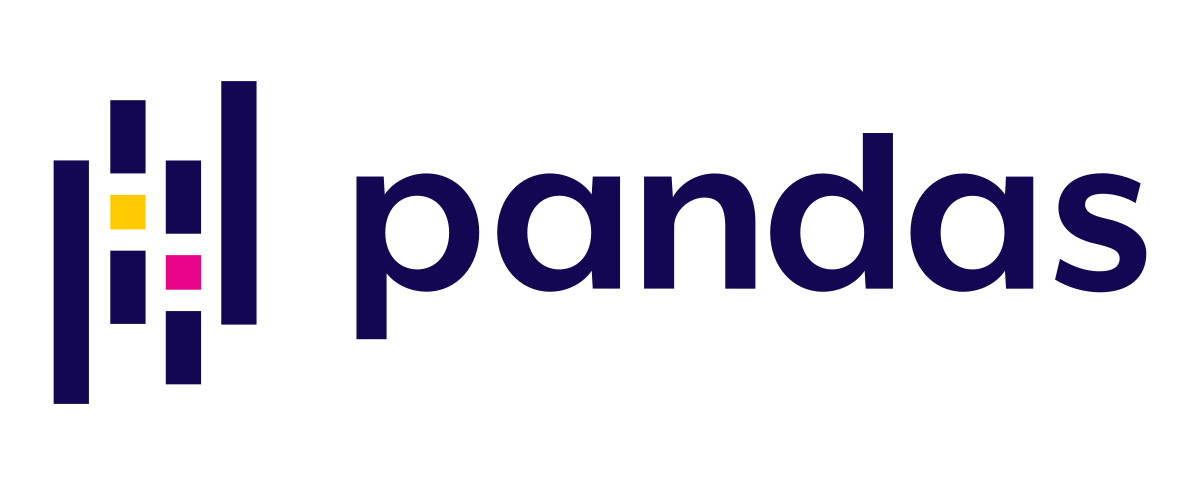

### What *is* <code>pandas</code>?

-  Very likely, one of the most important tool for a (Pythonist) Data Scientist!

-  It contains data structures and data manipulation tools designed to make data **cleaning** and **analysis** fast and easy in Python.

-  Acronym derived from "**p**ython **an**d **d**ata **a**nalysi**s**" or, maybe, "**pan**el **da**ta".

### What Does It Provide Us With?

-  Often used in tandem with numerical computing tools like <code>**numpy**</code> and <code>**scipy**</code>, as well as machine learning modules like <code>**scikit-learn**</code> and <code>**statsmodels**</code>, and data visualization libraries like <code>**matplotlib**</code> and <code>seaborn</code>.

-  It uses significant parts of <code>**numpy**</code> style of array-based computing, especially vectorized functions for data processing without <code>**for**</code> loops.

-  You can find more about <code>**pandas**</code> on the official [website](http://pandas.pydata.org/).

### 0.4 Reading an error

When something goes wrong, Python prints a **traceback**. The most useful piece
is usually the *last line*: it tells you the type of error and a short message.

Example:
```
KeyError: 'prize'
```
means you asked for a column called `'prize'` and pandas didn't find it.
(Probably you meant `'price'`.)

Don't be afraid of red text. **Read the last line first.**

### 0.5 Importing libraries

Every notebook starts with imports. We will use these throughout the course:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display options for nicer output
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

# Make plots show up inline (default in Jupyter, explicit doesn't hurt)
%matplotlib inline

The aliases `pd`, `np`, `plt`, `sns` are universal conventions. If you write
`import pandas` and then `pandas.read_csv(...)`, your code works but no human
reader will recognize it as idiomatic. Stick to the conventions.

> **🛑 LLM checkpoint.** Ask your LLM: *"What's the difference between
> `import pandas` and `import pandas as pd`?"* Then ask: *"Why do people
> always write `as pd`?"* The first answer is technical, the second is about
> *convention* — LLMs are good at both, but the second is the kind of thing
> nobody teaches you formally.

---
## 1. Loading the data and the first look

We have a CSV file with rental listings in Milan. Let's open it.

In [3]:
# Adjust this path to where you saved the file.
# In Colab, after uploading: '/content/rentals_milan.csv'
# Locally: './rentals_milan.csv' or wherever it is.
df = pd.read_csv('rentals_milan.csv')

In [4]:
from google.colab import drive
drive.mount('/content/drive')
df_tmp = pd.read_csv('/content/drive/MyDrive/rentals_milan.csv')

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/rentals_milan.csv'

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/fpinell/hands_on_python_for_ds/refs/heads/main/data/rentals_milan.csv')

`pd.read_csv` is one of the most flexible functions in pandas. It has
~50 parameters. We will discover the most useful ones organically.

The first thing to do with a new DataFrame is **look at it from three angles**:

In [7]:
df.shape

(2513, 19)

How many rows and columns? Always know this number before doing anything else.

In [9]:
df.head(10)

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description
0,ML-2025-02054,07/01/2025,Corvetto,900,52,3,2,1,6,True,furnished,heat pump,E,1996.0,M3,170.0,1,temporary,"Two-bedroom, with elevator, near metro M3."
1,ML-2025-01838,2024-10-04,Porta Garibaldi,€ 950,44,3,3,1,first,False,partly furnished,autonomous,NaN,NaN,NaN,NaN,1,temporary,"Two-bedroom, in historic building, near metro M5."
2,ML-2025-00514,2025-02-17,Quarto Oggiaro,850,88,4,3,1,2,False,partly furnished,autonomous,NaN,1932.0,NaN,250.0,1,student,"Apartment, in historic building, near metro M3."
3,ML-2025-00778,2025-01-23,DE ANGELI,1950,93,4,4,1,5,True,unfurnished,heat pump,A,2020.0,M1,190.0,1,temporary,"Apartment, recently built, with elevator, near..."
4,ML-2025-00803,2024-10-07,Sempione,2000,73,2,1,1,4,True,furnished,autonomous,E,1951.0,M5,270.0,3,4+4,"One-bedroom, with elevator, near metro M5."
5,ML-2025-01034,10/05/2024,Porta Romana,1800,68,2,1,2,first,True,partly furnished,autonomous,C,2008.0,M3,70.0,2,3+2,"One-bedroom, with elevator, near metro M3."
6,ML-2025-00802,2024-12-17,Porta Romana,1250,51,2,1,1,3,True,furnished,autonomous,G,1968.0,NaN,200.0,2,4+4,"One-bedroom, with elevator, near metro M3."
7,ML-2025-02145,24/03/2025,Città Studi,1000,59,4,3,1,3,True,unfurnished,central,F,1987.0,M2,180.0,3,4+4,"Apartment, with elevator, near metro M2."
8,ML-2025-01815,2025-02-10,Porta Venezia,950,32,1,1,1,4th,True,furnished,autonomous,C,2013.0,M1,60.0,2,4+4,"Studio, recently built, with elevator, near me..."
9,ML-2025-01260,2024-11-16,Zone Sempione,1850,90,4,3,1,3,True,unfurnished,autonomous,NaN,2003.0,M5,140.0,3,4+4,"Apartment, with elevator, near metro M5."


`head()` shows the first 5 rows. Use `df.tail()` for the last 5,
or `df.sample(10)` for 10 random rows (often more informative than the head,
because the head is sometimes systematically different from the rest).

In [10]:
df.sample(10, random_state=0)

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description
2058,ML-2025-02081,2025-02-09,Centro Storico,950,34,1,1,1,2,False,furnished,autonomous,G,1932.0,M1,90.0,3,3+2,"Studio, in historic building, near metro M1."
616,ML-2025-02430,2024-11-02,Baggio,1050,92,4,3,1,6,True,partly furnished,heat pump,E,1984.0,NaN,180.0,1,temporary,"Apartment, with elevator."
2007,ML-2025-01344,2025-03-23,De Angeli,1850,101,3,2,2,4th,True,furnished,autonomous,NaN,1931.0,M1,230.0,3,4+4,"Large apartment, in historic building, with el..."
2411,ML-2025-00797,31 January 2025,Corvetto,550,42,2,1,1,1,True,unfurnished,central,E,1996.0,M3,120.0,2,4+4,NaN
2277,ML-2025-00298,2025-02-22,Navigli,1350,72,3,2,1,2th,True,unfurnished,autonomous,NaN,1914.0,M2,320.0,3,4+4,"Two-bedroom, in historic building, with elevat..."
1598,ML-2025-01668,01/22/2025,Corvetto,600,51,2,1,1,1,False,partly furnished,autonomous,F,1978.0,M3,220.0,2,4+4,"One-bedroom, near metro M3."
2053,ML-2025-01388,08/01/2025,Porta Romana,1650,63,4,3,2,2,True,furnished,central,F,1978.0,NaN,150.0,2,3+2,"Apartment, with elevator, near metro M3."
1500,ML-2025-01935,2025-02-11,Lambrate,2050,116,6,5,2,4,True,furnished,autonomous,D,1995.0,M2,60.0,2,4+4,"Large apartment, with elevator, near metro M2."
1683,ML-2025-02409,2025-01-12,Lorenteggio,350,33,1,1,1,2th,False,unfurnished,autonomous,F,NaN,NaN,140.0,3,4+4,"Studio, in historic building."
2475,ML-2025-00229,29/01/2025,Baggio,450,35,3,2,1,1st,False,furnished,central,G,1946.0,NaN,70.0,3,4+4,"Studio, in historic building."


**`random_state=0`** fixes the random seed: the same call gives the same
rows every time. This matters for reproducibility — without it, you cannot
re-run the notebook and get the same output.

### 1.1 What types are the columns?

This is the question that surprises beginners the most.

In [11]:
df.dtypes

,0
id,object
listing_date,object
neighborhood,object
price,object
sqm,object
rooms,int64
bedrooms,int64
bathrooms,int64
floor,object
elevator,bool


Look carefully. We have:

- `int64` columns (`rooms`, `bedrooms`, `bathrooms`, `deposit_months`)
- `float64` columns (`year_built`, `condo_fees`)
- `bool` for `elevator`
- `object` for **a lot of things** — including `price` and `sqm`!

`object` in pandas usually means *Python strings*. Why are `price` and `sqm`
strings? They should be numbers. Let's investigate.

In [12]:
df['price'].head(20)

,price
0,900
1,€ 950
2,850
3,1950
4,2000
5,1800
6,1250
7,1000
8,950
9,1850


In [16]:
df['sqm'].sample(20)

,sqm
940,81
187,51
768,64
2493,61
746,55
1113,79
1178,71
2427,51
1773,24
2413,64


Some values look like `1500`, others like `'€ 1500'` or `'55 sqm'`.
The presence of even one non-numeric value forces the whole column to be `object`.

> **This is the kind of problem you find every day in real data.** If you don't
> notice it now, every later operation (`.mean()`, `.sum()`, plotting) will
> either fail or — worse — silently do the wrong thing.

We will fix this in the **cleaning** section. For now, just notice it.

### 1.2 A summary in one call

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2513 non-null   object 
 1   listing_date    2513 non-null   object 
 2   neighborhood    2513 non-null   object 
 3   price           2513 non-null   object 
 4   sqm             2513 non-null   object 
 5   rooms           2513 non-null   int64  
 6   bedrooms        2513 non-null   int64  
 7   bathrooms       2513 non-null   int64  
 8   floor           2513 non-null   object 
 9   elevator        2513 non-null   bool   
 10  furnishing      2513 non-null   object 
 11  heating         2513 non-null   object 
 12  energy_class    1912 non-null   object 
 13  year_built      2331 non-null   float64
 14  nearest_metro   2187 non-null   object 
 15  condo_fees      2312 non-null   float64
 16  deposit_months  2513 non-null   int64  
 17  contract_type   2513 non-null   o

`info()` is one of the most useful methods in pandas. It tells you:

- the index range
- each column's dtype
- the number of **non-null** values per column → from this you can spot missing values
- memory usage

Compare the non-null counts: some columns have fewer than 2513 non-null values.
Those columns have missing data.

In [19]:
df.describe(percentiles=[.9,.95,.99])

,rooms,bedrooms,bathrooms,year_built,condo_fees,deposit_months
count,2513.000000,2513.000000,2513.000000,2331.000000,2312.000000,2513.000000
mean,3.023876,2.222045,1.353760,1972.305877,173.010381,2.126542
std,1.216030,1.121606,0.480722,39.115505,72.264023,0.793023
min,1.000000,1.000000,1.000000,1019.000000,50.000000,-2.000000
50%,3.000000,2.000000,1.000000,1980.000000,170.000000,2.000000
90%,5.000000,4.000000,2.000000,2015.000000,280.000000,3.000000
95%,5.000000,4.000000,2.000000,2019.000000,300.000000,3.000000
99%,6.000000,5.000000,2.000000,2022.700000,320.000000,3.000000
max,6.000000,6.000000,4.000000,2030.000000,320.000000,3.000000


`describe()` shows summary stats for **numeric columns only**.

Notice what is *missing* from this output: `price` and `sqm`. They are not
numeric (they are `object`), so `describe()` ignores them. This is one of the
costs of having dirty types: your summary tools silently skip half the data.

To get a summary of the non-numeric columns:

In [22]:
df.describe(include='all')

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description
count,2513,2513,2513,2513,2513,2513.000000,2513.000000,2513.000000,2513,2513,2513,2513,1912,2331.000000,2187,2312.000000,2513.000000,2513,2262
unique,2513,561,80,146,218,NaN,NaN,NaN,23,2,14,14,11,NaN,4,NaN,NaN,4,125
top,ML-2025-01160,2025-03-24,Città Studi,750,72,NaN,NaN,NaN,2,True,furnished,autonomous,G,NaN,M2,NaN,NaN,4+4,"Two-bedroom, with elevator, near metro M2."
freq,1,17,158,89,44,NaN,NaN,NaN,298,1719,988,1127,502,NaN,709,NaN,NaN,1328,73
mean,NaN,NaN,NaN,NaN,NaN,3.023876,2.222045,1.353760,NaN,NaN,NaN,NaN,NaN,1972.305877,NaN,173.010381,2.126542,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,1.216030,1.121606,0.480722,NaN,NaN,NaN,NaN,NaN,39.115505,NaN,72.264023,0.793023,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,1019.000000,NaN,50.000000,-2.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,1944.000000,NaN,110.000000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,3.000000,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,1980.000000,NaN,170.000000,2.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,2.000000,NaN,NaN,NaN,NaN,NaN,2002.000000,NaN,230.000000,3.000000,NaN,NaN


This shows count, unique, top (most frequent), freq.
Already we can see something suspicious: `heating` has `unique = 14`,
even though we'd expect 3 categories (autonomous, central, heat pump).
Why 14? We'll find out shortly.

### 1.3 Missing values at a glance

In [23]:
df.isna()

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2508,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2509,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2510,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2511,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
energy_class,601
nearest_metro,326
description,251
condo_fees,201
year_built,182
id,0
listing_date,0
neighborhood,0
price,0
rooms,0


`isna()` returns a DataFrame of booleans (True where the value is missing).
Summing booleans counts the `True`s.

**Three things to notice:**

1. `energy_class` and `year_built` have many missing values.
2. `nearest_metro` has missing values too — but here it's *expected*: not every
   neighbourhood has a metro stop nearby.
3. The `description` column shows 0 missing — but earlier I said some
   descriptions were empty. **Empty strings are not NaN.** This is a classic
   trap.

In [24]:
# Empty strings vs NaN: count them separately
(df['description'] == '').sum()

np.int64(0)

So we have ~250 empty descriptions that `isna()` does **not** count as
missing. Whether to treat empty strings as missing is a *decision* — it
depends on your analysis. The point is: pandas won't make this decision for you,
and neither will an LLM.

> **🛑 LLM checkpoint.** Open your favorite LLM and ask:
> *"How many missing values are in this dataset?"* (paste a few rows or the
> output of `df.isna().sum()`).
>
> See if it mentions the empty-strings issue **without you prompting it**.
> Most won't. This is exactly the kind of domain-aware check you have to add yourself.

---
## 2. Selecting and filtering rows

Real questions about the data sound like:

- *"How many apartments are below 1000 €/month?"*
- *"What are the cheapest rentals in Brera?"*
- *"How many recent buildings (after 2015) have an elevator?"*

To answer them we need to **select** subsets of the DataFrame.

### 2.1 Selecting columns

In [ ]:
# A single column → returns a Series
df['neighborhood'].head()

,neighborhood
0,Corvetto
1,Porta Garibaldi
2,Quarto Oggiaro
3,DE ANGELI
4,Sempione


In [ ]:
# Multiple columns → returns a DataFrame (note the double brackets!)
df[['neighborhood', 'price', 'sqm']].head()

,neighborhood,price,sqm
0,Corvetto,900,52
1,Porta Garibaldi,€ 950,44
2,Quarto Oggiaro,850,88
3,DE ANGELI,1950,93
4,Sempione,2000,73


The double brackets are not a typo. `df['neighborhood']` returns a `Series`;
`df[['neighborhood']]` returns a `DataFrame` with one column. Different objects,
different methods available. This is one of the small gotchas that LLMs
sometimes get wrong, mixing the two.

### 2.2 Selecting rows: `.loc` and `.iloc`

There are two access methods, and **they do different things**:

- `.loc[...]` selects by **label** (index value, column name)
- `.iloc[...]` selects by **integer position** (always 0-based)

In [26]:
# By position
df.iloc[0]          # first row, all columns

,0
id,ML-2025-02054
listing_date,07/01/2025
neighborhood,Corvetto
price,900
sqm,52
rooms,3
bedrooms,2
bathrooms,1
floor,6
elevator,True


In [27]:
df.iloc[0:3]        # first three rows

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description
0,ML-2025-02054,07/01/2025,Corvetto,900,52,3,2,1,6,True,furnished,heat pump,E,1996.0,M3,170.0,1,temporary,"Two-bedroom, with elevator, near metro M3."
1,ML-2025-01838,2024-10-04,Porta Garibaldi,€ 950,44,3,3,1,first,False,partly furnished,autonomous,NaN,NaN,NaN,NaN,1,temporary,"Two-bedroom, in historic building, near metro M5."
2,ML-2025-00514,2025-02-17,Quarto Oggiaro,850,88,4,3,1,2,False,partly furnished,autonomous,NaN,1932.0,NaN,250.0,1,student,"Apartment, in historic building, near metro M3."


In [31]:
df.iloc[100:110, 1:4]

,listing_date,neighborhood,price
100,2024-12-01,Magenta,1000
101,15/03/2025,Zone Magenta,1950
102,02/02/2025,Quarto Oggiaro,1000
103,2024-10-25,Città Studi,1850
104,2025-03-18,Quarto Oggiaro,850
105,2025-02-04,Bicocca,2400
106,2024-12-03,Lorenteggio,550
107,2025-03-10,Baggio,750
108,2025-03-14,Lambrate,750
109,2025-03-04,Corvetto,1200


In [28]:
df.iloc[0:3, 1:4]   # first three rows, columns 1–3

,listing_date,neighborhood,price
0,07/01/2025,Corvetto,900
1,2024-10-04,Porta Garibaldi,€ 950
2,2025-02-17,Quarto Oggiaro,850


In [33]:
df.head(1)

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description
0,ML-2025-02054,07/01/2025,Corvetto,900,52,3,2,1,6,True,furnished,heat pump,E,1996.0,M3,170.0,1,temporary,"Two-bedroom, with elevator, near metro M3."


In [32]:
# By label
df.loc[0, 'neighborhood']           # row with index label 0, column 'neighborhood'

'Corvetto'

In [ ]:
df.loc[0:3, ['neighborhood', 'price']]   # rows 0–3 (inclusive!), specific columns

,neighborhood,price
0,Corvetto,900
1,Porta Garibaldi,€ 950
2,Quarto Oggiaro,850
3,DE ANGELI,1950


⚠️ **Watch this difference**: `iloc[0:3]` returns 3 rows (0, 1, 2 — Python slice).
`loc[0:3]` returns 4 rows (0, 1, 2, 3 — both endpoints inclusive). This is
genuinely confusing the first time. The reason is that `.loc` works on labels,
not positions, and slicing labels inclusively is more intuitive when labels
are non-numeric (like dates).

### 2.3 Boolean filtering — the workhorse

This is how you actually answer questions on data.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2513 non-null   object 
 1   listing_date    2513 non-null   object 
 2   neighborhood    2513 non-null   object 
 3   price           2513 non-null   object 
 4   sqm             2513 non-null   object 
 5   rooms           2513 non-null   int64  
 6   bedrooms        2513 non-null   int64  
 7   bathrooms       2513 non-null   int64  
 8   floor           2513 non-null   object 
 9   elevator        2513 non-null   bool   
 10  furnishing      2513 non-null   object 
 11  heating         2513 non-null   object 
 12  energy_class    1912 non-null   object 
 13  year_built      2331 non-null   float64
 14  nearest_metro   2187 non-null   object 
 15  condo_fees      2312 non-null   float64
 16  deposit_months  2513 non-null   int64  
 17  contract_type   2513 non-null   o

In [ ]:
df.describe()

,rooms,bedrooms,bathrooms,year_built,condo_fees,deposit_months
count,2513.000000,2513.000000,2513.000000,2331.000000,2312.000000,2513.000000
mean,3.023876,2.222045,1.353760,1972.305877,173.010381,2.126542
std,1.216030,1.121606,0.480722,39.115505,72.264023,0.793023
min,1.000000,1.000000,1.000000,1019.000000,50.000000,-2.000000
25%,2.000000,1.000000,1.000000,1944.000000,110.000000,1.000000
50%,3.000000,2.000000,1.000000,1980.000000,170.000000,2.000000
75%,4.000000,3.000000,2.000000,2002.000000,230.000000,3.000000
max,6.000000,6.000000,4.000000,2030.000000,320.000000,3.000000


In [ ]:
df.dtypes

,0
id,object
listing_date,object
neighborhood,object
price,object
sqm,object
rooms,int64
bedrooms,int64
bathrooms,int64
floor,object
elevator,bool


In [34]:
# Apartments under 1000 €/month — but wait...
try:
    result = df[df['price'] < 1000]
    print(f"Returned {len(result)} rows.")
except TypeError as e:
    print(f"Got a TypeError: {e}")

Got a TypeError: '<' not supported between instances of 'str' and 'int'


Boom. The `price` column is `object` (it contains strings like `'€ 1500'`),
so the comparison `< 1000` is asking pandas to compare strings to integers,
which it refuses to do.

This is actually the *good* outcome — we get a loud error. In older pandas
versions, or in some cases, the comparison silently returns wrong results.
Either way, **the lesson is the same**: never trust comparison/aggregation on
columns whose dtype you haven't checked.

We'll fix this in the cleaning section. For now, let's filter on a column
that *is* clean:

In [ ]:
(df['elevator'] == True) & (df['year_built'] > 2015)

,0
0,False
1,False
2,False
3,True
4,False
...,...
2508,False
2509,True
2510,False
2511,False


In [38]:
df_tmp = df[(df['elevator'] == True) & (df['year_built'] > 2015)].copy()

In [36]:
# Apartments with elevator, on a high floor
df[(df['elevator'] == True) & (df['year_built'] > 2015)].head()

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description
3,ML-2025-00778,2025-01-23,DE ANGELI,1950,93,4,4,1,5,True,unfurnished,heat pump,A,2020.0,M1,190.0,1,temporary,"Apartment, recently built, with elevator, near..."
31,ML-2025-01377,24/02/2025,NoLo,1400,81,4,3,1,8,True,unfurnished,heat pump,B,2021.0,M1,210.0,1,temporary,NaN
61,ML-2025-01434,11/20/2024,Lambrate,700,38,2,1,1,4,True,unfurnished,central,A,2023.0,M2,220.0,3,3+2,"Studio, recently built, with elevator, near me..."
69,ML-2025-01209,2025-01-10,Isola,900,45,2,1,1,7th,True,empty,autonomous,A4,2016.0,M5,80.0,3,3+2,"One-bedroom, recently built, with elevator, ne..."
83,ML-2025-01332,06/10/2024,De Angeli,1950,76,2,1,1,3,True,furnished,autonomous,A2,2022.0,M1,130.0,3,4+4,"One-bedroom, recently built, with elevator, ne..."


Two things to notice:

1. **Parentheses are required** around each condition when combining with `&` (and) or `|` (or).
   Forgetting them gives a confusing error about ambiguous truth values.
2. We use `&`/`|`, **not** `and`/`or`. The Python keywords `and`/`or` work on
   single booleans, not on Series.

In [37]:
# .isin() for "value in list"
df[df['neighborhood'].isin(['Brera', 'Quadrilatero', 'Centro Storico'])].head()

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description
27,ML-2025-00819,02/02/2025,Brera,2900,94,4,3,2,4,True,unfurnished,central,E,1985.0,M2,210.0,1,temporary,"Apartment, with elevator, near metro M2."
32,ML-2025-00473,2025-02-19,Brera,1900,72,4,3,1,1st,False,unfurnished,central,NaN,1952.0,M3,150.0,2,4+4,"Apartment, near metro M3."
48,ML-2025-00937,03/23/2025,Centro Storico,1800,59,3,2,1,7,True,Unfurnished,central,C,2011.0,M1,160.0,3,4+4,"Two-bedroom, recently built, with elevator, ne..."
58,ML-2025-00084,2024-10-31,Quadrilatero,3950,104,4,4,1,1,False,furnished,autonomous,NaN,1954.0,M1,90.0,2,4+4,"Large apartment, near metro M1."
78,ML-2025-02242,2024-10-27,Brera,1300,45,3,2,1,1st,False,unfurnished,central,G,1953.0,M2,180.0,2,4+4,"Two-bedroom, near metro M2."


> **🛑 LLM checkpoint.** Ask your LLM: *"Find all apartments in Brera
> under 2000 €/month."* Look carefully at the answer.
>
> Did it write `df[df['price'] < 2000]` without checking the dtype? Did it
> notice that `'Brera'` might also be spelled `'brera'` or `'BRERA'` in the data?
> If neither — that's why we are still in the room.

---
## 3. Data cleaning — where the real work happens

Cleaning is typically 60–80% of the time on any real dataset.
This section is the longest of the lecture for that reason.

We'll fix, in order:

1. Mixed types (`price`, `sqm`, `floor`)
2. Inconsistent encoding (`heating`, `furnishing`, `neighborhood`)
3. Date formats (`listing_date`)
4. Missing values (and the difference between *missing at random* and *structurally missing*)
5. Duplicates
6. Logical errors (negative deposits, impossible rooms, etc.)

### 3.1 Mixed types in `price` and `sqm`

Let's see exactly which values are problematic.

In [40]:
# Find rows where prezzo is not purely a number
non_numeric_prezzo = df['price'].astype(str).str.contains(r'[^\d]', regex=True)


In [41]:
non_numeric_prezzo

,price
0,False
1,True
2,False
3,False
4,False
...,...
2508,False
2509,False
2510,False
2511,False


In [42]:
df[non_numeric_prezzo][['price']]

,price
1,€ 950
29,€ 900
35,€ 2800
47,€ 700
52,€ 1300
...,...
2446,€ 700
2457,€ 1000
2471,€ 2050
2489,€ 1650


In [43]:
df.loc[non_numeric_prezzo, 'price'].head(10)

,price
1,€ 950
29,€ 900
35,€ 2800
47,€ 700
52,€ 1300
76,€ 1150
141,€ 900
170,€ 850
176,€ 1300
183,€ 2700


Some have a `€` sign. To convert them all to numbers, we need to:

1. Make sure everything is a string
2. Strip non-digit characters
3. Convert to numeric

A common mistake is to call `pd.to_numeric` directly:

In [44]:
# This will FAIL or coerce to NaN — try it
pd.to_numeric(df['price'], errors='coerce').isna().sum()

np.int64(125)

`errors='coerce'` turns failed conversions into `NaN`. We just lost
~125 rows of price information silently. **Always check how many NaNs
appeared after a conversion.**

The right approach: clean *first*, convert *after*.

In [47]:
(df['price'].astype(str)
                .str.replace('€', '', regex=False)
                .str.replace(' ', '', regex=False)
                .astype(int))

,price
0,900
1,950
2,850
3,1950
4,2000
...,...
2508,1850
2509,1950
2510,1850
2511,160


In [45]:
# Strip currency symbols, spaces, and 'sqm' units
df['price'] = (df['price'].astype(str)
                .str.replace('€', '', regex=False)
                .str.replace(' ', '', regex=False)
                .astype(int))


,0
price,int64
sqm,int64


In [51]:
non_numeric_sqm = df['sqm'].astype(str).str.contains(r'[\d]', regex=True)


In [ ]:
df['sqm']

In [52]:
non_numeric_sqm.sum()


np.int64(2513)

In [53]:

df['sqm'] = (df['sqm'].astype(str)
            .str.replace('sqm', '', regex=False)
            .str.strip()
            .astype(int))

df[['price', 'sqm']].dtypes

,0
price,int64
sqm,int64


In [54]:
df.columns

Index(['id', 'listing_date', 'neighborhood', 'price', 'sqm', 'rooms', 'bedrooms', 'bathrooms', 'floor', 'elevator',
       'furnishing', 'heating', 'energy_class', 'year_built', 'nearest_metro', 'condo_fees', 'deposit_months',
       'contract_type', 'description'],
      dtype='object')

In [60]:
df[(df['neighborhood'] == 'Brera') & (df['price']< 2000)].shape

(18, 19)

Now `price` and `sqm` are integers. Let's verify nothing was lost:

In [61]:
df.shape  # should still be 2513

(2513, 19)

In [62]:
df[['price', 'sqm']].describe()

,price,sqm
count,2513.000000,2513.000000
mean,1451.602865,71.035018
std,873.213628,29.599092
min,80.000000,0.000000
25%,900.000000,50.000000
50%,1300.000000,66.000000
75%,1800.000000,86.000000
max,14902.000000,250.000000


### 3.2 The `floor` column — a real headache

This column has values like `'T'`, `'PT'`, `'piano terra'`, `'1'`, `'1°'`, `'primo'`, `'5'`...

In [ ]:
df['floor'].value_counts().head(20)

,count
floor,
2,298
3,277
1,253
4,233
5,170
3th,162
2th,157
4th,121
6,93


A naive approach would be `pd.to_numeric(errors='coerce')` — but that
throws away every textual value. We'd lose all ground floors. Instead, we
build an **explicit mapping**.

In [63]:
# Define a mapping function
def normalize_floor(x):
    x = str(x).strip().lower()
    # Ground floor variants
    if x in ['g', 'gf', 'ground floor', 'ground', '0']:
        return 0
    if x in ['1', '1st', 'first']:
        return 1
    # Try direct conversion (for plain numbers like '5' or '5th')
    try:
        return int(x.replace('th', '').replace('rd', '').replace('nd', '').replace('st', ''))
    except ValueError:
        return None  # we'll see what's left

df['normalized_floor'] = df['floor'].apply(normalize_floor)

df['floor'] = df['floor'].apply(normalize_floor)
df['floor'].value_counts(dropna=False).sort_index()

,count
floor,
0,189
1,424
2,455
3,439
4,354
5,259
6,135
7,134
8,123


In [68]:
df.head(2)

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,normalized_floor
0,ML-2025-02054,07/01/2025,Corvetto,900,52,3,2,1,6,True,furnished,heat pump,E,1996.0,M3,170.0,1,temporary,"Two-bedroom, with elevator, near metro M3.",6
1,ML-2025-01838,2024-10-04,Porta Garibaldi,950,44,3,3,1,1,False,partly furnished,autonomous,NaN,NaN,NaN,NaN,1,temporary,"Two-bedroom, in historic building, near metro M5.",1


In [69]:
df[df['energy_class'].isna()]

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,normalized_floor
1,ML-2025-01838,2024-10-04,Porta Garibaldi,950,44,3,3,1,1,False,partly furnished,autonomous,NaN,NaN,NaN,NaN,1,temporary,"Two-bedroom, in historic building, near metro M5.",1
2,ML-2025-00514,2025-02-17,Quarto Oggiaro,850,88,4,3,1,2,False,partly furnished,autonomous,NaN,1932.0,NaN,250.0,1,student,"Apartment, in historic building, near metro M3.",2
9,ML-2025-01260,2024-11-16,Zone Sempione,1850,90,4,3,1,3,True,unfurnished,autonomous,NaN,2003.0,M5,140.0,3,4+4,"Apartment, with elevator, near metro M5.",3
12,ML-2025-00025,2024-11-06,Città Studi,1850,89,4,4,2,3,True,unfurnished,autonomous,NaN,1925.0,M2,90.0,3,4+4,"Apartment, in historic building, with elevator...",3
15,ML-2025-01154,2025-02-24,Lambrate,1400,73,4,3,1,7,True,PARTLY,central,NaN,1981.0,M2,190.0,2,4+4,"Apartment, with elevator, near metro M2.",7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2492,ML-2025-00579,2024-12-08,Città Studi,900,50,2,1,1,5,True,unfurnished,centr.,NaN,1947.0,NaN,70.0,3,4+4,NaN,5
2499,ML-2025-01609,2024-10-20,Navigli,1250,59,4,3,1,3,False,furnished,autonomous,NaN,1934.0,M2,NaN,2,4+4,"Apartment, in historic building, near metro M2.",3
2500,ML-2025-00380,21 January 2025,Isola,1400,78,2,1,2,3,False,partly furnished,heat pump,NaN,1944.0,M5,120.0,1,student,"One-bedroom, in historic building, near metro M5.",3
2502,ML-2025-02114,2024-12-30,Baggio,850,69,2,1,2,4,True,unfurnished,central,NaN,1995.0,NaN,140.0,1,temporary,"One-bedroom, with elevator.",4


In [64]:
df['floor'].isna().sum()

np.int64(0)

In [ ]:
df['normalized_floor'].value_counts(dropna=False)

,count
normalized_floor,
2,455
3,439
1,424
4,354
5,259
0,189
6,135
7,134
8,123


**`apply` applied a function to every value in the column.** It's the
swiss-army knife of pandas: when no built-in method does what you want, write
a function and apply it.

Now `floor` is numeric (with possibly some `None`/NaN if some values weren't
covered by our mapping). Always check for what got lost:

In [ ]:
df['floor'].isna().sum()

np.int64(0)

### 3.3 Inconsistent categorical values

Look at `heating`:

In [71]:
df.describe(include='object')


,id,listing_date,neighborhood,furnishing,heating,energy_class,nearest_metro,contract_type,description
count,2513,2513,2513,2513,2513,1912,2187,2513,2262
unique,2513,561,80,14,14,11,4,4,125
top,ML-2025-01160,2025-03-24,Città Studi,furnished,autonomous,G,M2,4+4,"Two-bedroom, with elevator, near metro M2."
freq,1,17,158,988,1127,502,709,1328,73


We have 14 distinct values where there should be 3. Most are
trivial variants: spaces, capitalization, abbreviations.

A naive cleanup is `.str.strip().str.lower()`:

In [72]:
df['heating'].str.strip().str.lower().value_counts()

,count
heating,
autonomous,1299
central,809
heat pump,254
centr.,95
auto.,44
hp,8
heatpump,4


That helped — we went from 14 to fewer values — but **abbreviations
are still there** (`'auto.'`, `'centr.'`, `'pdc'`). This is exactly where LLM
suggestions often stop, and where a human eye is needed.

We need a proper mapping:

In [73]:
heating_map = {
    'autonomous': 'autonomous',
    'auto.': 'autonomous',
    'central': 'central',
    'centr.': 'central',
    'heat pump': 'heat pump',
    'heatpump': 'heat pump',
    'hp': 'heat pump',
}

df['heating'] = (df['heating']
                       .str.strip().str.lower()
                       .map(heating_map))

df['heating'].value_counts(dropna=False)

,count
heating,
autonomous,1343
central,904
heat pump,266


**`map`** is similar to `apply`, but takes a *dictionary* (or function)
and is typically used for value-by-value substitutions. The result is now
clean: 3 categories, no NaN.

> **Pattern to remember.** Whenever you "clean" a categorical column, the
> diagnostic is simple: **count the categories before and after, and check
> that the after count matches your expectation.** If you expected 3 and got
> 5, you didn't finish the job.

Apply the same logic to `furnishing` and `neighborhood` (left as exercise — or as
LLM checkpoint).

> **🛑 LLM checkpoint.** Ask your LLM: *"Clean the `furnishing` column
> in this DataFrame: it should have only 3 distinct values."*
>
> Then check: did it produce a mapping like ours, or did it just call
> `.str.lower().str.strip()` and stop? If it stopped, count the unique values
> in the result. Are they 3?

In [ ]:
# Quick clean of `furnishing`
furnishing_map = {
    'furnished': 'furnished',
    'furn.': 'furnished',
    'unfurnished': 'unfurnished',
    'unfurn.': 'unfurnished',
    'empty': 'unfurnished',
    'partly furnished': 'partly furnished',
    'partly furn.': 'partly furnished',
    'partly': 'partly furnished',
}

df['furnishing'] = (df['furnishing']
                     .str.strip().str.lower()
                     .map(furnishing_map))

df['furnishing'].value_counts(dropna=False)

,count
furnishing,
furnished,1123
unfurnished,744
partly furnished,646


In [ ]:
# Clean `neighborhood`: strip 'Zone ' prefix, normalize case
df['neighborhood'] = (df['neighborhood']
              .str.replace(r'^Zone\s+', '', regex=True, case=False)
              .str.strip()
              .str.title())

df['neighborhood'].value_counts().head(10)

,count
neighborhood,
Città Studi,167
Navigli,161
Lambrate,136
Nolo,135
Bicocca,135
Isola,126
Porta Romana,125
Porta Venezia,123
Lorenteggio,121


### 3.4 Date formats

`listing_date` has dates in multiple formats: ISO `2025-03-15`, European
`15/03/2025`, US `03/15/2025` (**ambiguous!**), and even `'15 March 2025'`.

In [ ]:
df['listing_date'].head(15)

,listing_date
0,07/01/2025
1,2024-10-04
2,2025-02-17
3,2025-01-23
4,2024-10-07
5,10/05/2024
6,2024-12-17
7,24/03/2025
8,2025-02-10
9,2024-11-16


The naive call:

In [74]:
# Try the naive approach
parsed_naive = pd.to_datetime(df['listing_date'], errors='coerce')
parsed_naive.isna().sum()

np.int64(2028)

Some are NaT (Not a Time — pandas' missing-date marker). Worse:
the ones that *parsed* may have day and month swapped due to the US format.
This is the most insidious kind of bug, because it doesn't raise an error.

A more careful approach: try multiple formats explicitly.

In [75]:
def parse_date(s):
    if pd.isna(s):
        return pd.NaT
    s = str(s).strip()
    formats_to_try = ['%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y']
    for fmt in formats_to_try:
        try:
            return pd.to_datetime(s, format=fmt)
        except (ValueError, TypeError):
            continue
    # Extended format: "15 March 2025"
    months = {
        'january': '01', 'february': '02', 'march': '03', 'april': '04',
        'may': '05', 'june': '06', 'july': '07', 'august': '08',
        'september': '09', 'october': '10', 'november': '11', 'december': '12'
    }
    for month_name, month_num in months.items():
        if month_name in s.lower():
            parts = s.lower().replace(month_name, month_num).split()
            if len(parts) == 3:
                try:
                    return pd.to_datetime(f"{parts[0]}-{parts[1]}-{parts[2]}",
                                          format='%d-%m-%Y')
                except ValueError:
                    pass
    return pd.NaT

df['listing_date'] = df['listing_date'].apply(parse_date)
df['listing_date'].dtype

dtype('<M8[ns]')

**Even this is imperfect.** When we encounter `'03/05/2025'`, we still
don't know if it's March 5 or May 3. Real data ingestion sometimes requires
a domain choice (e.g. "we know the source is Italian, so dd/mm always wins").
The lesson is: *parsing dates is not a one-liner*.

In [76]:
df['listing_date'].describe()

,listing_date
count,2513
mean,2025-01-03 01:10:28.889773056
min,2024-01-11 00:00:00
25%,2024-11-19 00:00:00
50%,2025-01-02 00:00:00
75%,2025-02-19 00:00:00
max,2025-12-01 00:00:00


### 3.5 Missing values — and a crucial concept

A common reflex is to call `df.dropna()` or `df.fillna(0)` and move on.
**Don't.** Missing values can mean very different things:

- **Missing completely at random (MCAR)** — the missingness has no pattern.
  Rare in practice.
- **Missing at random (MAR)** — missingness depends on observed variables.
- **Missing not at random (MNAR)** — missingness depends on the missing value itself.

These distinctions affect what's safe to do.

Look at our `energy_class` column:

In [77]:
df['energy_class'].isna().sum()

np.int64(601)

In [ ]:
# Where are the missing values? Plot the distribution of construction year for missing vs not
df.groupby(df['energy_class'].isna())['year_built'].agg(['mean', 'count'])

,mean,count
energy_class,,
False,1976.147092,1788
True,1959.657459,543


See how the average construction year for the rows with missing energy
class is much **lower** than for the others. **The missingness is not random.**

This makes sense: the *Attestato di Prestazione Energetica* (APE) became
mandatory in Italy only in 2005. Buildings constructed before that often
don't have a recorded energy class.

What does this mean for our analysis?

- `dropna()` would systematically delete old buildings → biased dataset.
- `fillna('C')` (the most common class) would say old buildings have average
  efficiency, which is the opposite of true.
- A reasonable choice is to **keep NaN as a category of its own** ("unknown"),
  because the fact of being missing carries information.

In [80]:
df['energy_class'] = df['energy_class'].fillna('unknown')

In [81]:
df['energy_class'].value_counts()

,count
energy_class,
unknown,601
G,502
F,393
E,278
D,240
C,186
B,105
A,80
A2,46


> **🛑 LLM checkpoint — important.** Paste a few rows of this dataset to
> your LLM and ask: *"How should I handle the missing values in
> `energy_class`?"*
>
> The most likely answers are: drop, fill with mode, or fill with a constant.
> Most LLMs **will not investigate whether the missingness is structured**
> unless you explicitly tell them to. This is a research-quality decision,
> and the responsibility for it is yours.

### 3.6 Duplicates

In [ ]:
# Exact duplicates (same content, possibly different `id`)
exact_dupes = df.duplicated(subset=df.columns.difference(['id']), keep=False)
exact_dupes.sum()

np.int64(10)

We pass `subset=...` to ignore `id` (which is unique by construction).
`keep=False` marks **all** duplicate rows (not just the second occurrence),
which is what we want for inspection.

Let's drop them, keeping the first occurrence:

In [ ]:
before = len(df)
df = df.drop_duplicates(subset=df.columns.difference(['id']), keep='first')
print(f"Removed {before - len(df)} exact duplicates. Now: {len(df)} rows.")

Removed 0 exact duplicates. Now: 2508 rows.


**Always print "before / after" counts.** If you don't, you have no
guarantee that the operation did what you expected.

Near-duplicates (same listing reposted with a slightly different price) are
harder. There's no built-in for them — you'd need a custom rule, e.g.
"same `sqm`, same `neighborhood`, same `year_built`, prices within 10% of each
other". We won't tackle that today, but **be aware** that `drop_duplicates`
is not the end of the story.

### 3.7 Logical errors

Some values are simply impossible. We can find them with sanity checks.

In [ ]:
# Negative deposits?
df[df['deposit_months'] < 0]

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,normalized_floor
23,ML-2025-00028,2025-03-02,Città Studi,1550,79,3,2,2,1,False,unfurnished,central,F,1923.0,M2,120.0,-2,4+4,"Two-bedroom, in historic building, near metro M2.",1
1756,ML-2025-00494,2025-03-25,Magenta,2600,120,5,4,2,1,False,partly furnished,autonomous,F,1978.0,M1,270.0,-1,4+4,"Large apartment, near metro M1.",1


In [ ]:
# Zero square meters?
df[df['sqm'] == 0]

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,normalized_floor
143,ML-2025-00106,2025-02-01,Navigli,1250,0,3,2,2,5,True,furnished,autonomous,G,1949.0,M2,300.0,2,3+2,"Two-bedroom, in historic building, with elevat...",5


In [ ]:
# More rooms than total rooms?
df[df['bedrooms'] > df['rooms']]

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,normalized_floor
669,ML-2025-01544,2025-02-02,Navigli,900,38,2,3,1,2,False,partly furnished,central,E,NaN,M2,200.0,2,3+2,"Studio, in historic building, near metro M2.",2
2403,ML-2025-00202,2024-12-22,Porta Venezia,2200,105,4,6,1,2,False,partly furnished,autonomous,E,1933.0,M1,240.0,2,4+4,"Large apartment, in historic building, near me...",2


In [ ]:
# Construction year outside [1800, current year]?
df[(df['year_built'] < 1800) | (df['year_built'] > 2025)]

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,normalized_floor
560,ML-2025-01790,2025-02-20,Città Studi,1450,76,3,2,2,4,True,Partly furnished,autonomous,Sconosciuta,2030.0,M2,150.0,3,3+2,"Two-bedroom, with elevator, near metro M2.",4
2094,ML-2025-00343,2025-03-16,Magenta,4050,148,4,3,2,1,True,partly furnished,autonomous,Sconosciuta,1019.0,M1,120.0,2,4+4,"Large apartment, with elevator, near metro M1.",1


These are all clearly errors. Decide case by case whether to drop the
row, replace the value with NaN, or correct it manually. For this lecture,
let's drop them:

In [ ]:
mask_valid = (
    (df['deposit_months'].fillna(0) >= 0) &
    (df['sqm'] > 0) &
    (df['bedrooms'] <= df['rooms']) &
    (df['year_built'].fillna(2000).between(1800, 2025))
)

mask_valid.value_counts()

,count
True,2501
False,7


In [ ]:
mask_valid = (
    (df['deposit_months'].fillna(0) >= 0) &
    (df['sqm'] > 0) &
    (df['bedrooms'] <= df['rooms']) &
    (df['year_built'].fillna(2000).between(1800, 2025))
)
print(f"Dropping {(~mask_valid).sum()} rows that fail logical checks.")
df = df[mask_valid].reset_index(drop=True)
df.shape

Dropping 7 rows that fail logical checks.


(2501, 20)

### 3.8 Outliers — legit vs. errors

Look at the price distribution:

In [ ]:
df['price'].describe()

,price
count,2501.000000
mean,1448.651739
std,872.271067
min,80.000000
25%,900.000000
50%,1300.000000
75%,1800.000000
max,14902.000000


In [ ]:
# Top 10 highest prices
df.nlargest(10, 'price')[['neighborhood', 'sqm', 'price', 'description']]

,neighborhood,sqm,price,description
751,Brera,111,14902,"Prestigious penthouse with panoramic view, lux..."
596,Centro Storico,95,11370,"Prestigious penthouse with panoramic view, lux..."
1385,Centro Storico,51,10484,"Prestigious penthouse with panoramic view, lux..."
1775,Brera,39,10073,"Prestigious penthouse with panoramic view, lux..."
2175,Quadrilatero,74,9789,"Prestigious penthouse with panoramic view, lux..."
2223,Quadrilatero,130,5950,"Large apartment, with elevator, near metro M1."
1722,Quadrilatero,133,5800,"Large apartment, in historic building, with el..."
2177,Bocconi,250,5750,"Large apartment, near metro M3."
150,Città Studi,210,5250,"Large apartment, with elevator, near metro M2."
874,Porta Garibaldi,149,4550,"Large apartment, with elevator, near metro M2."


Some are genuinely luxury apartments in Brera or Centro — those are
**legitimate outliers** and should be kept. Others might be data-entry errors.

A naive "remove outliers with 3-sigma" or IQR rule would throw away both.
A better approach: use a **price-per-square-meter** sanity check.

In [ ]:
df['price_per_sqm'] = df['price'] / df['sqm']
df['price_per_sqm'].describe()

,price_per_sqm
count,2501.000000
mean,20.431548
std,9.434142
min,1.808511
25%,15.476190
50%,19.847328
75%,24.038462
max,258.282051


In [ ]:
# Outliers in either direction on price/mq?
import numpy as np
q1, q3 = df['price_per_sqm'].quantile([0.01, 0.99])
print(f"99% of listings have prezzo/mq between {q1:.1f} and {q3:.1f}")
df[(df['price_per_sqm'] < q1) | (df['price_per_sqm'] > q3)][
    ['neighborhood', 'sqm', 'price', 'price_per_sqm','description']].head(10)

99% of listings have prezzo/mq between 9.2 and 38.7


,neighborhood,sqm,price,price_per_sqm,description
106,Baggio,89,750,8.426966,"Apartment, in historic building."
184,Quarto Oggiaro,94,850,9.042553,"Apartment, in historic building, with elevator..."
366,Quadrilatero,93,4000,43.010753,"Apartment, in historic building, with elevator..."
434,Quarto Oggiaro,116,1050,9.051724,"Large apartment, in historic building, near me..."
452,Quadrilatero,31,1500,48.387097,NaN
463,Centro Storico,71,3000,42.253521,"Two-bedroom, recently built, with elevator, ne..."
472,Quarto Oggiaro,41,350,8.536585,"One-bedroom, in historic building, with elevat..."
492,Quarto Oggiaro,61,500,8.196721,"One-bedroom, near metro M3."
596,Centro Storico,95,11370,119.684211,"Prestigious penthouse with panoramic view, lux..."
632,Quarto Oggiaro,62,550,8.870968,"Apartment, in historic building, near metro M3."


Now we can see the suspicious cases more clearly. The rest of the
"outliers in absolute price" are simply **expensive but reasonable** for
their size — luxury apartments. We **don't drop them**.

---
## 4. Aggregation: groupby, value_counts, pivot

Once data is clean, summary becomes meaningful.

### 4.1 `groupby`

The most-used pandas idiom. Pattern: **split-apply-combine**.

In [ ]:
# Average price by zone
df.groupby('neighborhood')['price'].mean().sort_values(ascending=False).head(10)

,price
neighborhood,
Quadrilatero,2683.486486
Brera,2661.574074
Centro Storico,2388.418605
Bocconi,1830.530973
Porta Garibaldi,1752.104348
Isola,1668.809524
Porta Romana,1664.400000
Porta Venezia,1648.770492
Magenta,1641.279070


In [ ]:
# Multiple aggregations at once
df_gb = df.groupby('neighborhood')['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).head(10)

In [ ]:
df_gb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, Quadrilatero to Tortona
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mean    10 non-null     float64
 1   median  10 non-null     float64
 2   count   10 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 320.0+ bytes


In [ ]:
df_gb = df.groupby('neighborhood',as_index=False)['price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).head(10)

In [ ]:
df_gb.head()

,neighborhood,mean,median,count
19,Quadrilatero,2683.486486,2350.0,37
4,Brera,2661.574074,2300.0,54
5,Centro Storico,2388.418605,2075.0,86
3,Bocconi,1830.530973,1700.0,113
16,Porta Garibaldi,1752.104348,1750.0,115


In [ ]:
# Group by two keys
df.groupby(['neighborhood', 'contract_type'],as_index=False)['price'].mean().head(15)

,neighborhood,contract_type,price
0,Affori,3+2,930.952381
1,Affori,4+4,963.333333
2,Affori,student,910.000000
3,Affori,temporary,881.850000
4,Baggio,3+2,1102.631579
5,Baggio,4+4,879.761905
6,Baggio,student,868.181818
7,Baggio,temporary,817.647059
8,Bicocca,3+2,1368.750000
9,Bicocca,4+4,1370.547945


### 4.2 `value_counts`

Quick way to see the distribution of a categorical variable.

In [ ]:
df['contract_type'].value_counts()

,count
contract_type,
4+4,1321
3+2,547
temporary,386
student,247


In [ ]:
# As percentages
df['contract_type'].value_counts(normalize=True) * 100

,proportion
contract_type,
4+4,52.818872
3+2,21.871251
temporary,15.433826
student,9.876050


### 4.3 `pivot_table`

In [ ]:
# Average price by zone × contract type
pivot = df.pivot_table(
    values='price',
    index='neighborhood',
    columns='contract_type',
    aggfunc='mean'
)
pivot.head(10)

contract_type,3+2,4+4,student,temporary
neighborhood,,,,
Affori,930.952381,963.333333,910.000000,881.850000
Baggio,1102.631579,879.761905,868.181818,817.647059
Bicocca,1368.750000,1370.547945,1261.538462,1211.764706
Bocconi,1580.000000,1853.508772,2244.444444,1886.363636
Brera,3028.692308,2678.923077,2125.000000,2342.307692
Centro Storico,2706.380952,2313.191489,2200.000000,2222.727273
Città Studi,1618.055556,1471.195652,1352.631579,1300.000000
Corvetto,1190.000000,851.818182,807.692308,1057.692308
De Angeli,1246.153846,1592.000000,1740.909091,1400.000000


`pivot_table` is just a more flexible `groupby` for the case where you
want a 2D table. The same result can always be achieved with `groupby` +
`unstack`, but `pivot_table` is more readable.

---
## 5. Merging with another table

We have a second file, `zone_milan.csv`, with extra info per zone:
distance to the Duomo, average income, transport score.

In [ ]:
zones = pd.read_csv('zones_milan.csv')
zones

,neighborhood,distance_duomo_km,avg_income_eur,transport_score
0,Centro storico,0.5,55000,9
1,Brera,0.8,62000,8
2,Quadrilatero,0.4,75000,9
3,Porta Venezia,1.5,48000,8
4,Porta Romana,2.2,45000,8
5,Magenta,1.8,50000,8
6,Navigli,2.5,42000,8
7,Isola,3.0,40000,8
8,Porta Garibaldi,2.0,52000,9
9,Tortona,3.5,44000,7


Now merge it with our main DataFrame:

In [ ]:
before = len(df)
df_merged = df.merge(zones, on='neighborhood', how='left')
print(f"Before: {before} rows. After: {len(df_merged)} rows.")
print(f"Rows that didn't match: {df_merged['distance_duomo_km'].isna().sum()}")

Before: 2501 rows. After: 2501 rows.
Rows that didn't match: 165


**Always print before/after, and check for NaN on the right-hand columns.**
Some rows didn't match — let's see why.

In [ ]:
df_merged.sample(20)

,id,listing_date,neighborhood,price,sqm,rooms,bedrooms,bathrooms,floor,elevator,furnishing,heating,energy_class,year_built,nearest_metro,condo_fees,deposit_months,contract_type,description,normalized_floor,price_per_sqm,distance_duomo_km,avg_income_eur,transport_score
2462,ML-2025-00749,2025-01-18,Baggio,450,48,2,1,1,1,False,unfurnished,central,Sconosciuta,1930.0,NaN,270.0,1,temporary,"One-bedroom, in historic building.",1,9.375000,7.0,31000.0,5.0
1388,ML-2025-01182,2025-02-06,Porta Garibaldi,1300,52,1,1,1,4,True,furnished,autonomous,G,1969.0,M5,120.0,3,4+4,"Apartment, with elevator, near metro M5.",4,25.000000,2.0,52000.0,9.0
1097,ML-2025-01532,2024-11-04,Sempione,1050,53,2,1,1,3,False,unfurnished,heat pump,F,NaN,M1,90.0,3,4+4,"One-bedroom, in historic building, near metro M1.",3,19.811321,2.0,43000.0,8.0
2202,ML-2025-00914,2024-10-30,Nolo,800,46,2,2,1,5,True,unfurnished,autonomous,B,2017.0,M2,70.0,3,4+4,"One-bedroom, recently built, with elevator, ne...",5,17.391304,4.0,38000.0,7.0
1810,ML-2025-01517,2024-12-22,Bicocca,2200,105,4,3,1,7,True,furnished,central,A1,2021.0,M5,60.0,3,4+4,"Large apartment, recently built, with elevator...",7,20.952381,6.5,35000.0,7.0
663,ML-2025-01063,2025-01-04,Affori,400,31,2,1,1,4,True,partly furnished,central,G,1909.0,M3,230.0,2,4+4,"Studio, in historic building, with elevator, n...",4,12.903226,7.5,32000.0,6.0
2249,ML-2025-00184,2024-12-04,Baggio,1600,121,5,4,2,3,True,furnished,autonomous,E,1999.0,NaN,70.0,2,4+4,"Large apartment, with elevator.",3,13.223140,7.0,31000.0,5.0
435,ML-2025-02220,2024-10-14,Porta Venezia,1400,54,2,1,1,2,True,partly furnished,autonomous,C,2013.0,M1,80.0,3,3+2,NaN,2,25.925926,1.5,48000.0,8.0
121,ML-2025-00774,2024-11-16,Tortona,1350,53,1,1,1,6,True,furnished,heat pump,C,2010.0,M2,50.0,3,4+4,"Apartment, with elevator, near metro M2.",6,25.471698,3.5,44000.0,7.0
1080,ML-2025-00700,2025-03-17,Città Studi,1150,46,2,2,1,2,True,furnished,heat pump,E,1988.0,M2,240.0,1,temporary,"One-bedroom, with elevator, near metro M2.",2,25.000000,3.5,39000.0,8.0


In [ ]:
# Find unmatched zones
unmatched = df_merged[df_merged['distance_duomo_km'].isna()]['neighborhood'].unique()
unmatched

array(['De Angeli', 'Centro Storico'], dtype=object)

In [ ]:
# Compare: zones in zones file vs zones in main df
print("In main df, not in zones file:")
print(set(df['neighborhood'].unique()) - set(zones['neighborhood'].unique()))
print("\nIn zones file, not in main df:")
print(set(zones['neighborhood'].unique()) - set(df['neighborhood'].unique()))

In main df, not in zones file:
{'De Angeli', 'Centro Storico'}

In zones file, not in main df:
{'Centro storico', 'De angeli'}


The two files have the *same* zones, but with slightly different
spelling: `'Centro Storico'` vs `'Centro storico'`, `'NoLo'` vs `'Nolo'`,
`'De Angeli'` vs `'De angeli'`.

> **This is one of the most common bugs in real data engineering.** A merge
> that "works" can silently drop rows. Without the before/after check, you'd
> never notice.

Fix: normalize on both sides before merging.

In [ ]:
# Normalize both sides
df['zona_key'] = df['neighborhood'].str.lower()
zones['zona_key'] = zones['neighborhood'].str.lower()

df_merged = df.merge(zones.drop(columns='neighborhood'), on='zona_key', how='left')
print(f"Unmatched after fix: {df_merged['distance_duomo_km'].isna().sum()}")

Unmatched after fix: 0


> **🛑 LLM checkpoint.** Ask your LLM: *"Merge these two DataFrames on
> the `neighborhood` column."* See if it warns you about possible mismatches in
> spelling, or if it just gives you `df.merge(zones, on='neighborhood')` without
> a sanity check.

---
## 6. Visualization with matplotlib (and a taste of seaborn)

We end with the part that gives data its narrative power: **plotting**.

`matplotlib` is the foundational library. `seaborn` is a higher-level layer
on top of it, with prettier defaults and statistical shortcuts. `pandas`
itself has `.plot()` methods that wrap matplotlib.

Three things worth knowing up front:

1. There are **two APIs in matplotlib**: the "stateful" `plt.something()` and
   the "object-oriented" `fig, ax = plt.subplots()`. The OO API is
   recommended for anything beyond a quick plot. We'll use it.
2. A **figure** can contain multiple **axes** (subplots). Don't confuse the
   two.
3. Almost every plot starts with `fig, ax = plt.subplots(...)` and ends with
   labels, title, and `plt.show()`.

### 6.1 Histogram — the distribution of price

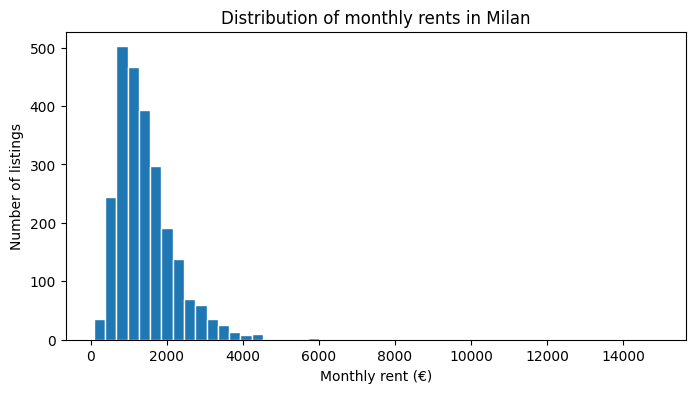

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['price'], bins=50, edgecolor='white')
ax.set_xlabel('Monthly rent (€)')
ax.set_ylabel('Number of listings')
ax.set_title('Distribution of monthly rents in Milan')
plt.show()

The distribution is right-skewed (a few very expensive listings pulling
the tail). When this happens, a log scale on the x-axis often helps:

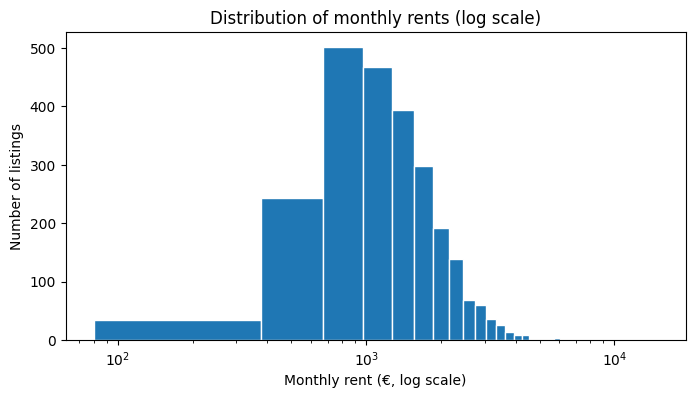

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['price'], bins=50, edgecolor='white')
ax.set_xscale('log')
ax.set_xlabel('Monthly rent (€, log scale)')
ax.set_ylabel('Number of listings')
ax.set_title('Distribution of monthly rents (log scale)')
plt.show()

### 6.2 Scatter plot — price vs square meters

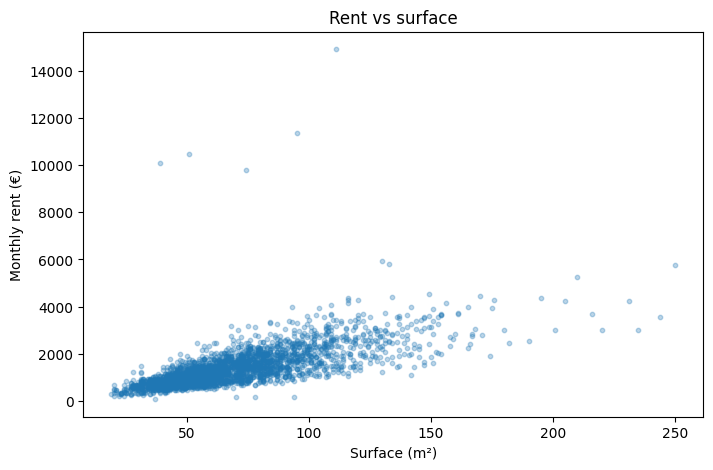

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['sqm'], df['price'], alpha=0.3, s=10)
ax.set_xlabel('Surface (m²)')
ax.set_ylabel('Monthly rent (€)')
ax.set_title('Rent vs surface')
plt.show()

**`alpha=0.3`** makes points semi-transparent — essential for scatter
plots with many points, otherwise overlapping points look the same as a
single point. Always use it when you have more than a few hundred points.

### 6.3 Bar plot — average price by zone

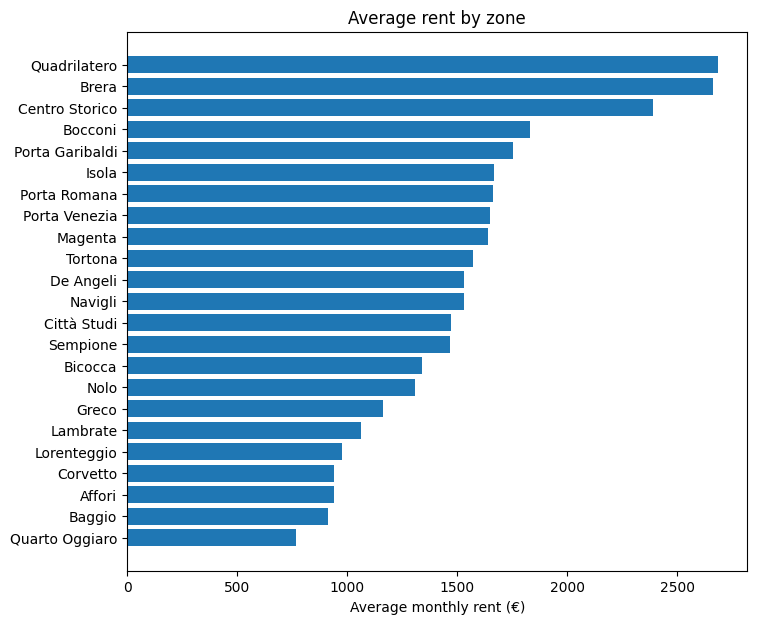

In [ ]:
avg_by_neighborhood = df.groupby('neighborhood')['price'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(avg_by_neighborhood.index, avg_by_neighborhood.values)
ax.set_xlabel('Average monthly rent (€)')
ax.set_title('Average rent by zone')
plt.show()

Horizontal bars (`barh`) are usually more readable than vertical bars
when the categories are many or have long names — vertical labels rotate and
become hard to read.

### 6.4 Boxplot — distribution by group

Boxplots are perfect for comparing distributions side by side.

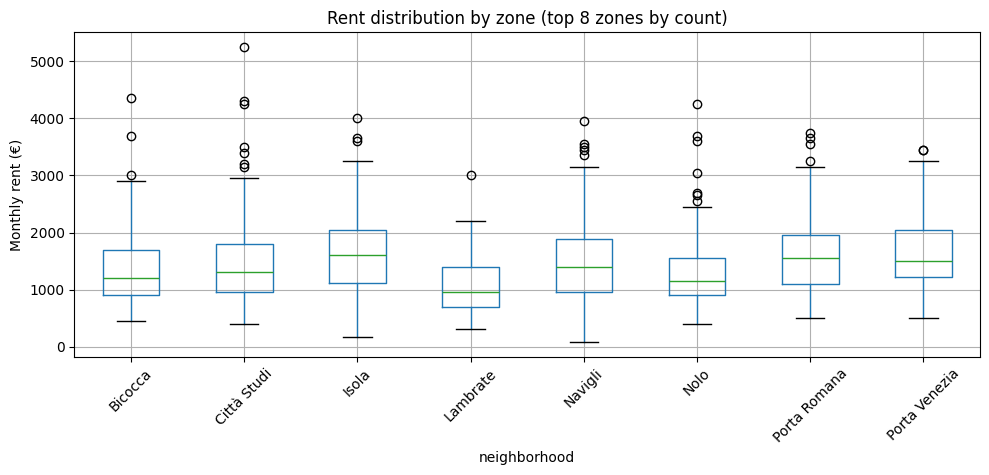

In [ ]:
# Pick a few zones for clarity
top_zones = df['neighborhood'].value_counts().head(8).index
df_top = df[df['neighborhood'].isin(top_zones)]

fig, ax = plt.subplots(figsize=(10, 5))
df_top.boxplot(column='price', by='neighborhood', ax=ax, rot=45)
ax.set_ylabel('Monthly rent (€)')
ax.set_title('Rent distribution by zone (top 8 zones by count)')
plt.suptitle('')  # remove the automatic super-title
plt.tight_layout()
plt.show()

### 6.5 Multiple subplots

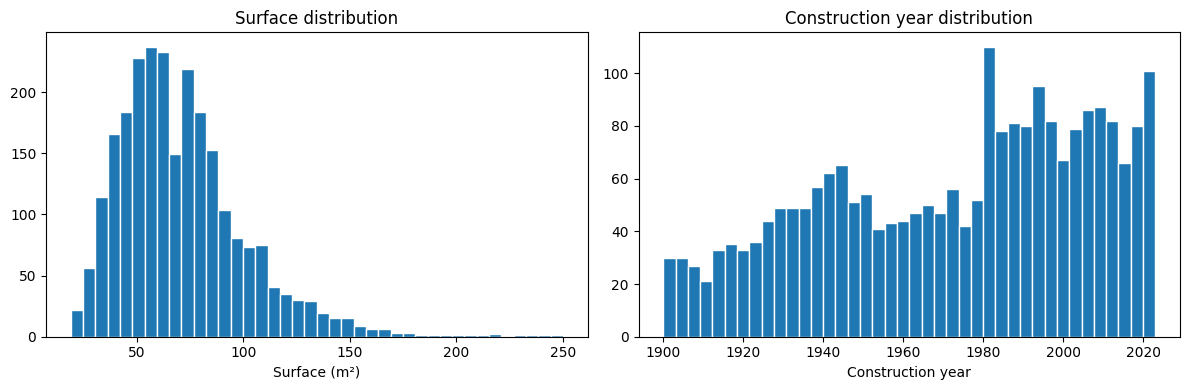

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['sqm'], bins=40, edgecolor='white')
axes[0].set_xlabel('Surface (m²)')
axes[0].set_title('Surface distribution')

axes[1].hist(df['year_built'].dropna(), bins=40, edgecolor='white')
axes[1].set_xlabel('Construction year')
axes[1].set_title('Construction year distribution')

plt.tight_layout()
plt.show()

### 6.6 A taste of seaborn

Seaborn shines for **statistical** plots. A few examples that are awkward
in plain matplotlib but trivial in seaborn:

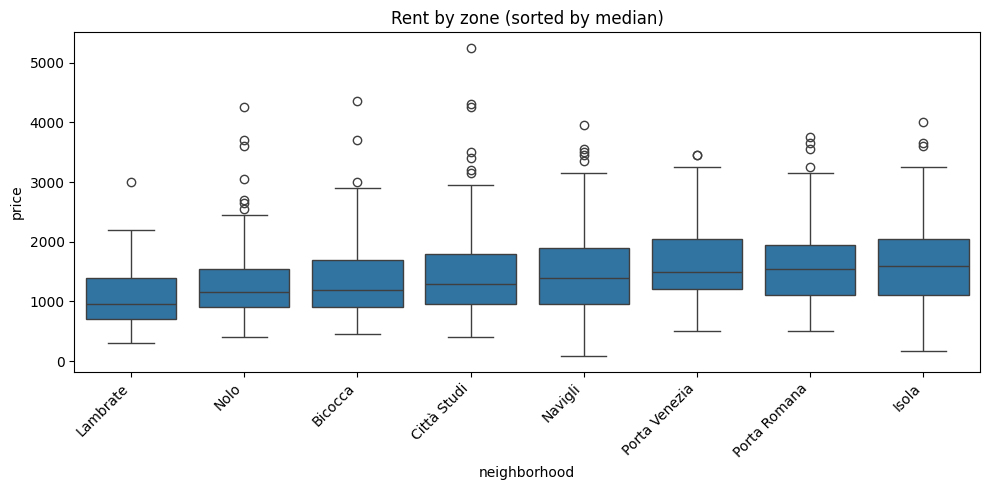

In [ ]:
# Distribution of price by zone (only top zones), with ordered categories
fig, ax = plt.subplots(figsize=(10, 5))
order = df_top.groupby('neighborhood')['price'].median().sort_values().index
sns.boxplot(data=df_top, x='neighborhood', y='price', ax=ax, order=order)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Rent by zone (sorted by median)')
plt.tight_layout()
plt.show()

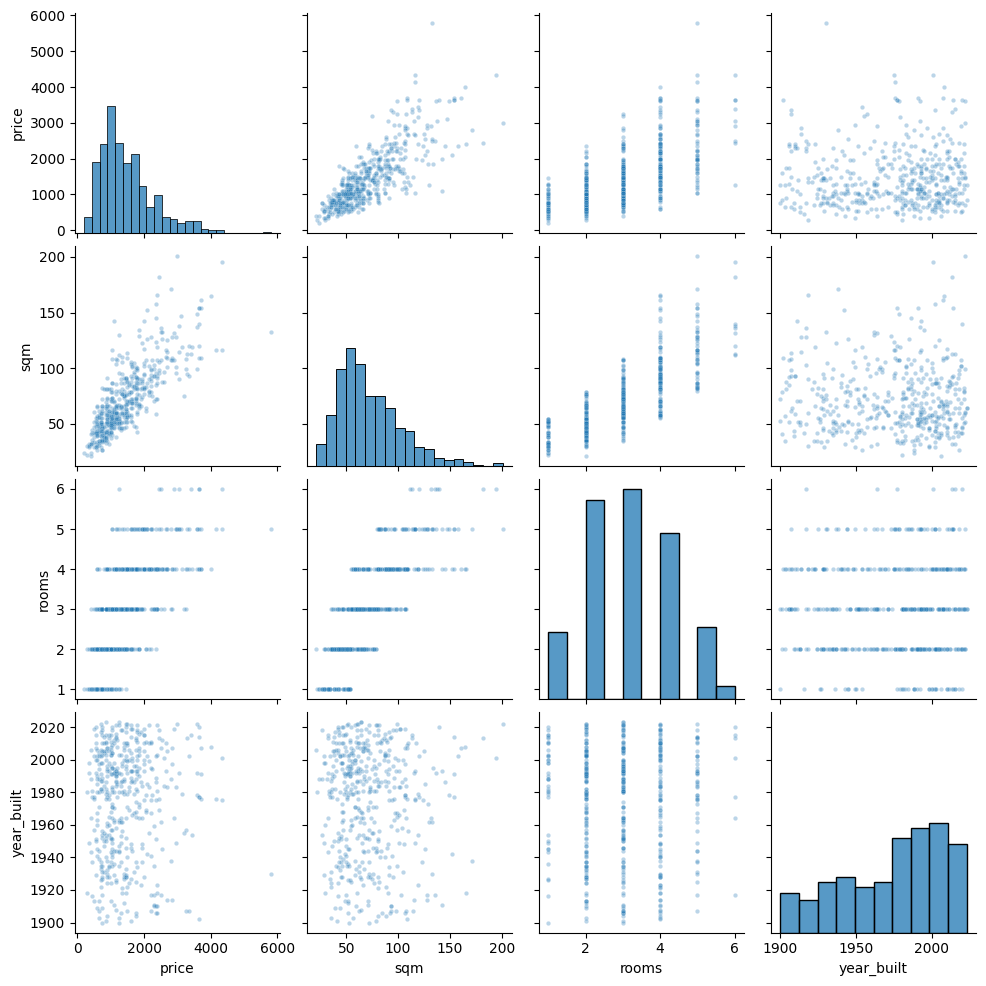

In [ ]:
# Pairwise relationships among numeric columns
sns.pairplot(df[['price', 'sqm', 'rooms', 'year_built']].sample(500),
             diag_kind='hist', plot_kws={'alpha': 0.3, 's': 10})
plt.show()

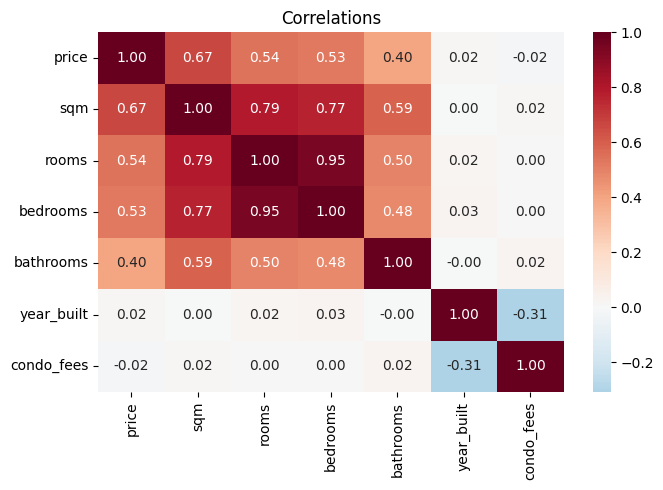

In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[['price', 'sqm', 'rooms', 'bedrooms', 'bathrooms',
           'year_built', 'condo_fees']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlations')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Create a sample Series to demonstrate the regex
sample_series = pd.Series([
    '52',
    '44 sqm',
    '88kg',
    '1950 dollars',
    'clean string',
    '123',
    '45 units here',
    'no number here'
])

# Apply the regex to find rows containing numbers followed by strings
pattern = r'\d+\s*[a-zA-Z]+'
contains_number_then_string = sample_series.str.contains(pattern, regex=True)

print("Original Series:")
print(sample_series)
print("\nRows containing numerical values followed by strings:")
print(contains_number_then_string)
print("\nFiltered rows:")
print(sample_series[contains_number_then_string])

### 6.7 A word on plot quality

The plots above are *functional*. They are not *publication-quality*. Going
from one to the other (axis labels with units, font sizes, color choices that
are colorblind-friendly, removed gridlines, annotation of important points)
is a separate skill — and one where LLMs are genuinely useful, because the
syntax is fiddly.

> **🛑 Final LLM checkpoint.** Pick one of the plots above and ask your LLM:
> *"Improve this plot for inclusion in a research paper."* See what it
> suggests. Most of the time the suggestions are good (clear axis labels,
> bigger fonts, clean style). The remaining 10% — that's where you have to
> notice and intervene.

---
## Wrap-up

Today we did **not** learn pandas as a reference manual. We learned pandas as
a sequence of tools to answer questions about a real dataset:

| Step | Tools |
|---|---|
| Load and inspect | `read_csv`, `head`, `shape`, `dtypes`, `info`, `describe`, `isna().sum()` |
| Select and filter | `[]`, `loc`, `iloc`, boolean indexing, `isin` |
| Clean | `astype`, `str.replace`, `apply`, `map`, `to_datetime`, `fillna`, `drop_duplicates` |
| Aggregate | `groupby`, `agg`, `value_counts`, `pivot_table` |
| Merge | `merge` (with sanity checks!) |
| Visualize | `matplotlib`, `seaborn`, `df.plot` |

**The common thread:** for every operation, ask yourself *"how do I check that
it did what I expected?"* — by counting rows before and after, by inspecting
unique values, by plotting distributions. This is the discipline that
separates "code that runs" from "results you can trust".

This is also exactly the discipline you need to **work productively with
LLMs**: their outputs always run, but they do not always do what you intended.
Verification is your job.

### What's next

Next lecture: from descriptive analysis to **modeling**